# MS_05 — SHAP Analysis (MzWarChrosci)

Loads C1_HGB models for h=6 and h=24 from `outputs/MzWarChrosci/models/`.
Runs `shap.TreeExplainer` on the full 2024 test set and produces:
- Beeswarm summary plot (top 20 features)
- Bar plot of mean |SHAP| values
- Dependence plots for top 3 features

All figures saved to `outputs/MzWarChrosci/figures/shap/`.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from src.config import DATA_PATH, TARGET, get_station_paths
from src.data_loader import load_data, train_test_split
from src.feature_engineering import build_feature_matrix, WEATHER_MODE_PERFECT_FULL
from src.utils import ensure_dirs

WEATHER_MODE = WEATHER_MODE_PERFECT_FULL

paths = get_station_paths(TARGET)
shap_dir = paths['figures'] / 'shap'
ensure_dirs(shap_dir)

print(f'TARGET: {TARGET}')
print(f'SHAP output dir: {shap_dir}')

TARGET: MzWarChrosci
SHAP output dir: D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\MzWarChrosci\figures\shap


In [2]:
df = load_data(DATA_PATH)
_, test_df = train_test_split(df)
print(f'Test set: {len(test_df):,} rows')

12:34:17 | src.data_loader | INFO | Loading data from D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\data\raw\FINAL_merged_PM25_1g_all_seasons.csv
12:34:17 | src.data_loader | INFO | Missing values per column:
MzOtwoBrzozo    1084
MzWarWokalna    2028
MzWarAlNiepo     575
MzLegZegrzyn    1511
MzPiasPulask    1002
MzWarChrosci     416
MzWarBajkowa     636
dir_48            48
dir_24            48
12:34:17 | src.data_loader | INFO | Loaded 52608 rows, 27 columns, range 2019-01-01 00:00:00 → 2024-12-31 23:00:00
12:34:17 | src.data_loader | INFO | Train: 43824 rows (2019-01-01 00:00:00 → 2023-12-31 23:00:00)
12:34:17 | src.data_loader | INFO | Test : 8784 rows (2024-01-01 00:00:00 → 2024-12-31 23:00:00)


Test set: 8,784 rows


12:34:18 | src.feature_engineering | INFO | build_feature_matrix | horizon=6 | weather_mode=perfect_forecast_full
12:34:18 | src.feature_engineering | INFO | perfect_forecast_full: shifted 8 MET + 10 HYSPLIT_NUM + 2 HYSPLIT_CAT by -6 h
12:34:18 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols



── h=6 ─────────────────────────────────────


12:34:18 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
12:34:18 | src.feature_engineering | INFO |   X: (7792, 45) | y mean=12.61, y std=8.38


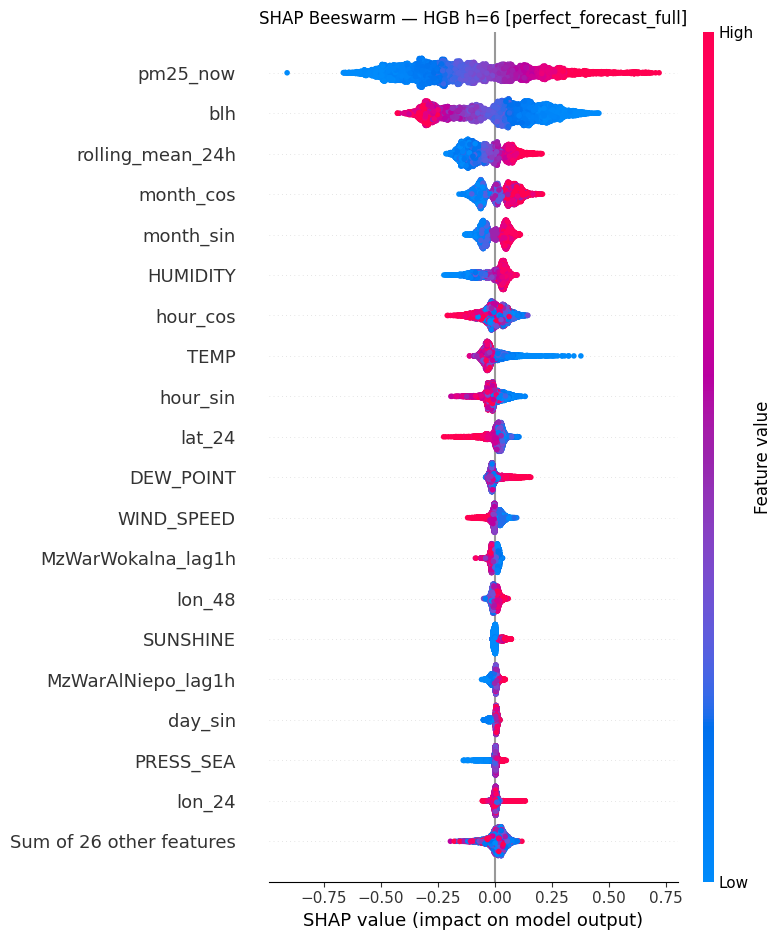

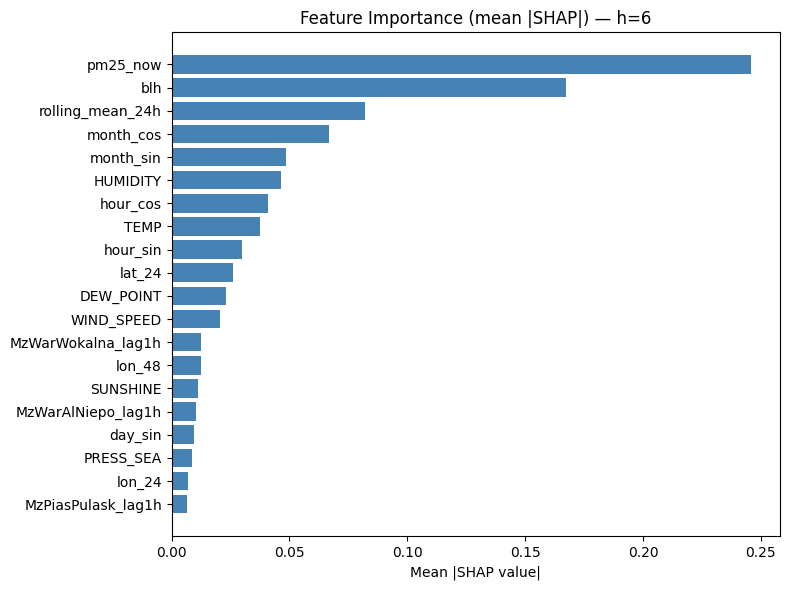

<Figure size 700x400 with 0 Axes>

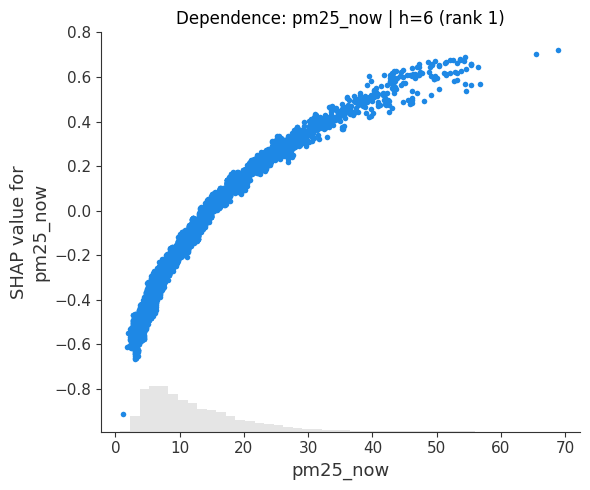

<Figure size 700x400 with 0 Axes>

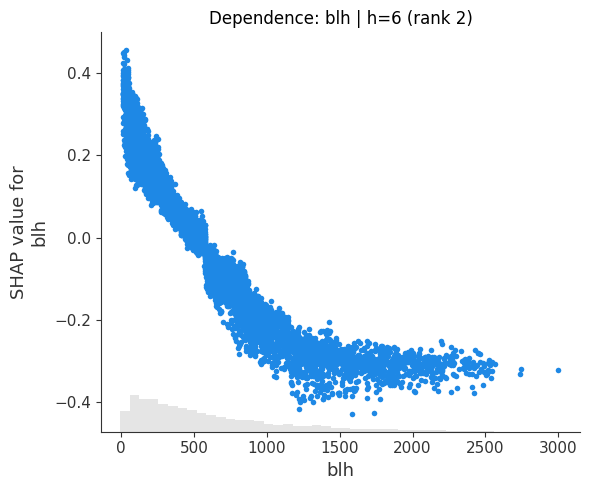

<Figure size 700x400 with 0 Axes>

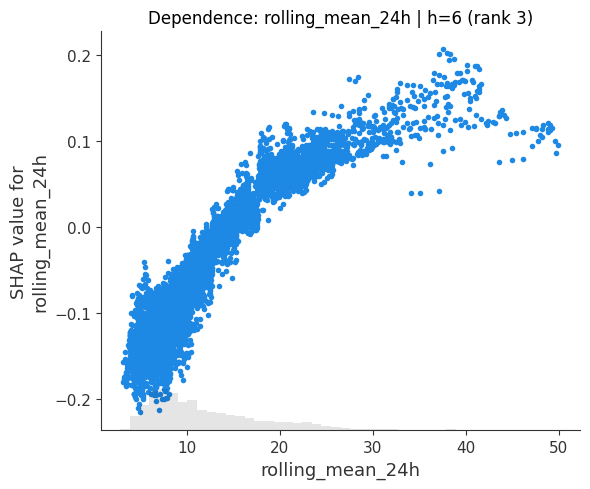

12:34:39 | src.feature_engineering | INFO | build_feature_matrix | horizon=24 | weather_mode=perfect_forecast_full
12:34:39 | src.feature_engineering | INFO | perfect_forecast_full: shifted 8 MET + 10 HYSPLIT_NUM + 2 HYSPLIT_CAT by -24 h
12:34:39 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
12:34:39 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
12:34:39 | src.feature_engineering | INFO |   X: (7766, 45) | y mean=12.60, y std=8.39


  Figures saved to D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\MzWarChrosci\figures\shap

── h=24 ─────────────────────────────────────


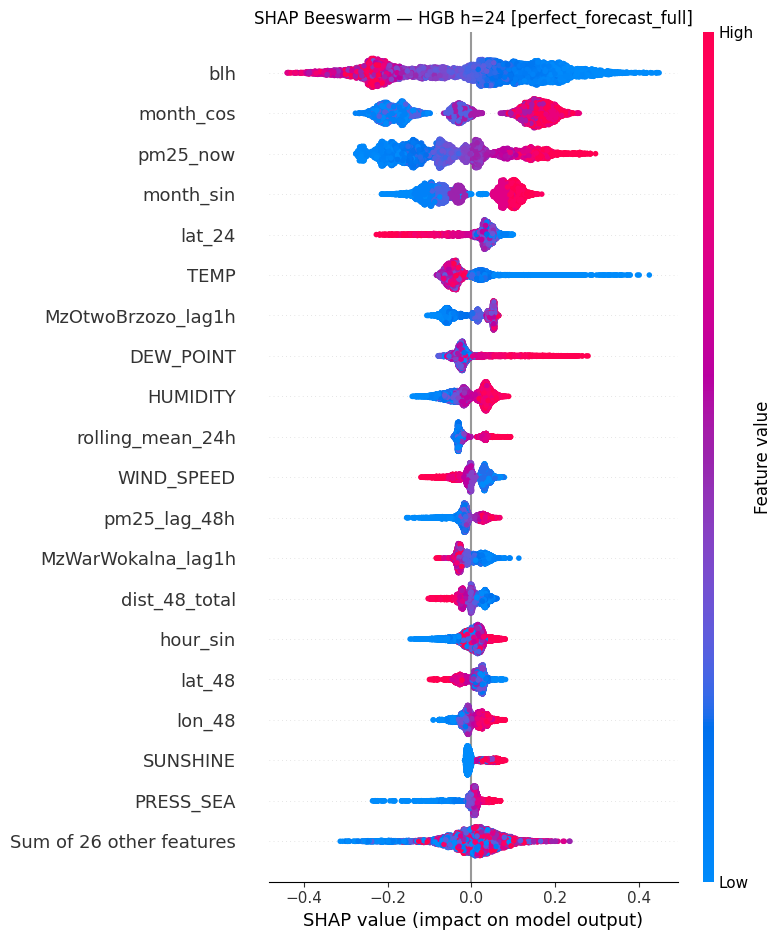

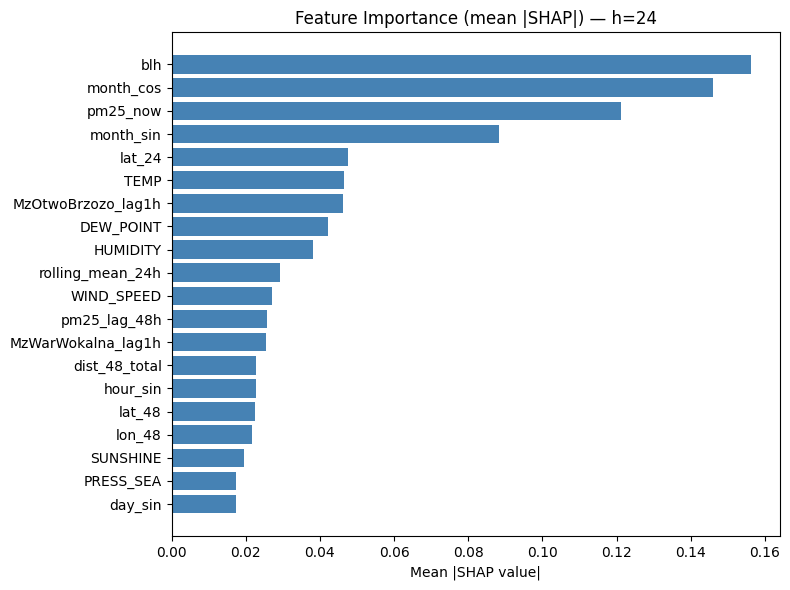

<Figure size 700x400 with 0 Axes>

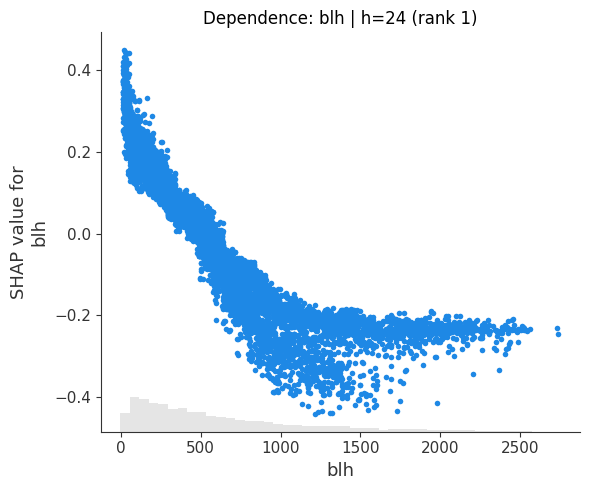

<Figure size 700x400 with 0 Axes>

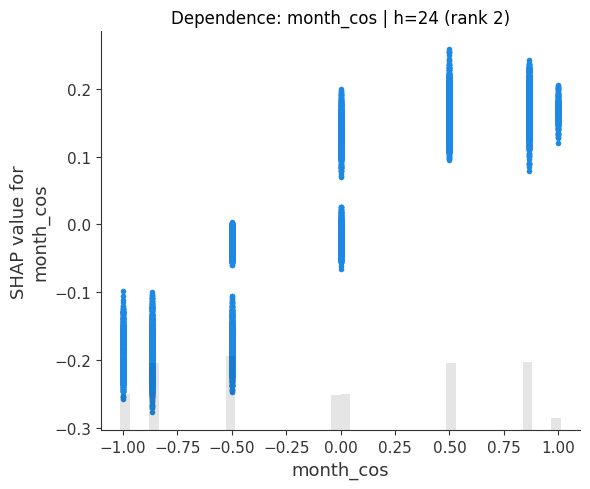

<Figure size 700x400 with 0 Axes>

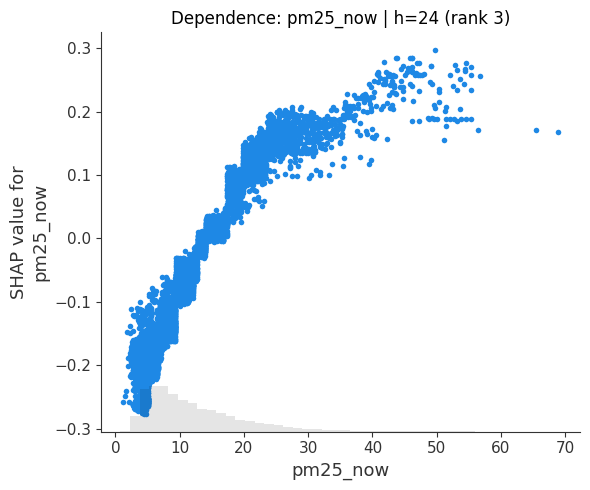

  Figures saved to D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\MzWarChrosci\figures\shap


In [3]:
top_features_by_horizon = {}  # h -> list of (feature_name, mean_abs_shap)

for h in [6, 24]:
    print(f'\n── h={h} ─────────────────────────────────────')

    # Load saved HGB model
    model_path = paths['models'] / f'hgb_pfxf_h{h}.pkl'
    if not model_path.exists():
        print(f'  [WARN] Model not found at {model_path}, skipping h={h}')
        continue
    model = joblib.load(model_path)

    # Build test feature matrix with the same weather_mode used during training
    X_test, y_test = build_feature_matrix(test_df, horizon=h, weather_mode=WEATHER_MODE)
    feature_names = X_test.columns.tolist()

    # Extract inner estimator from TransformedTargetRegressor
    inner_model = model.regressor_

    # SHAP TreeExplainer on full test set
    explainer = shap.TreeExplainer(inner_model)
    shap_explanation = explainer(X_test)
    shap_values = shap_explanation.values  # (n_samples, n_features)

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    ranked = sorted(zip(feature_names, mean_abs_shap), key=lambda x: x[1], reverse=True)
    top_features_by_horizon[h] = ranked

    # Beeswarm summary plot (top 20 features)
    fig = plt.figure(figsize=(10, 7))
    shap.plots.beeswarm(shap_explanation, max_display=20, show=False)
    plt.title(f'SHAP Beeswarm — HGB h={h} [perfect_forecast_full]')
    plt.tight_layout()
    fig.savefig(shap_dir / f'shap_beeswarm_h{h}.png', bbox_inches='tight')
    plt.show()
    plt.close(fig)

    # Bar plot of mean |SHAP|
    fig, ax = plt.subplots(figsize=(8, 6))
    names_top20 = [f for f, _ in ranked[:20]][::-1]
    vals_top20  = [v for _, v in ranked[:20]][::-1]
    ax.barh(names_top20, vals_top20, color='steelblue')
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(f'Feature Importance (mean |SHAP|) — h={h}')
    fig.tight_layout()
    fig.savefig(shap_dir / f'shap_bar_h{h}.png', bbox_inches='tight')
    plt.show()
    plt.close(fig)

    # Dependence plots for top 3 features
    for rank, (feat, _) in enumerate(ranked[:3], 1):
        if feat not in feature_names:
            continue
        feat_idx = feature_names.index(feat)
        fig = plt.figure(figsize=(7, 4))
        shap.plots.scatter(shap_explanation[:, feat_idx], show=False)
        plt.title(f'Dependence: {feat} | h={h} (rank {rank})')
        plt.tight_layout()
        fig.savefig(shap_dir / f'shap_dependence_h{h}_rank{rank}_{feat}.png', bbox_inches='tight')
        plt.show()
        plt.close(fig)

    print(f'  Figures saved to {shap_dir}')

In [4]:
# Side-by-side top-10 feature comparison: h=6 vs h=24
if 6 in top_features_by_horizon and 24 in top_features_by_horizon:
    top6  = [(f, round(v, 4)) for f, v in top_features_by_horizon[6][:10]]
    top24 = [(f, round(v, 4)) for f, v in top_features_by_horizon[24][:10]]

    print('\nTop 10 features by mean |SHAP|')
    print(f'{"Rank":<6} {"h=6 feature":<30} {"mean|SHAP|":>12}    {"h=24 feature":<30} {"mean|SHAP|":>12}')
    print('-' * 95)
    for rank, ((f6, v6), (f24, v24)) in enumerate(zip(top6, top24), 1):
        print(f'{rank:<6} {f6:<30} {v6:>12.4f}    {f24:<30} {v24:>12.4f}')
else:
    print('Could not produce comparison — one or both horizons missing.')


Top 10 features by mean |SHAP|
Rank   h=6 feature                      mean|SHAP|    h=24 feature                     mean|SHAP|
-----------------------------------------------------------------------------------------------
1      pm25_now                             0.2458    blh                                  0.1562
2      blh                                  0.1673    month_cos                            0.1460
3      rolling_mean_24h                     0.0819    pm25_now                             0.1212
4      month_cos                            0.0668    month_sin                            0.0882
5      month_sin                            0.0487    lat_24                               0.0475
6      HUMIDITY                             0.0465    TEMP                                 0.0465
7      hour_cos                             0.0408    MzOtwoBrzozo_lag1h                   0.0461
8      TEMP                                 0.0376    DEW_POINT                         